# EDA — Task 1 (OULAD)

This notebook looks at the **shape of the data** so we can set each feature's scaling from real
numbers instead of arbitrary caps. It covers:

1. How many students, and their final outcomes
2. **Clicks** — distribution and skew (decides percentile vs linear scaling)
3. **Active days** per week
4. **Activity types** available and used (Area 2 / breadth)
5. **Recency** — how big the silence gaps get
6. **Assessments** — how many, when due, submission and score patterns
7. **Cohort activity per week** — reveals whole-class dips (justifies Area 4)
8. **Feature correlation heatmap** — do the areas measure *different* things?
9. **Signal check** — do engaged students out-click those who withdraw?

In [2]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_data_dir():
    for d in ("datasets", "../datasets"):
        if os.path.isfile(os.path.join(d, "studentInfo.csv")):
            return d
    raise FileNotFoundError("Missing datasets/. Place OULAD CSV files in <project>/datasets/.")

DATA_DIR      = os.environ.get("OULAD_DIR", _find_data_dir())
MODULE        = None        # None = auto-pick biggest presentation
PRESENTATION  = None
DAYS_PER_WEEK = 7
EARLY_WEEKS   = 6
notes = []

def say(s=""):
    print(s); notes.append(str(s))

def _find(name):
    for f in os.listdir(DATA_DIR):
        if f.lower() == name.lower():
            return os.path.join(DATA_DIR, f)
    raise FileNotFoundError(f"Could not find '{name}' in '{DATA_DIR}'. Files: {os.listdir(DATA_DIR)}")

def pct_table(series, ps=(0,10,25,50,75,90,95,99,100)):
    s = series.dropna()
    return ", ".join(f"p{p}={np.percentile(s,p):.1f}" for p in ps) if len(s) else "no data"

## 1. Load the data and pick the course presentation

In [3]:
si  = pd.read_csv(_find("studentInfo.csv"))
sv  = pd.read_csv(_find("studentVle.csv"))
vle = pd.read_csv(_find("vle.csv"))
sa  = pd.read_csv(_find("studentAssessment.csv"))
asm = pd.read_csv(_find("assessments.csv"))

sizes = si.groupby(["code_module","code_presentation"]).size().sort_values(ascending=False)
if MODULE is None or PRESENTATION is None:
    MODULE, PRESENTATION = sizes.index[0]
say(f"Chosen presentation: {MODULE} {PRESENTATION}")
say("Top presentations by students:")
for (m,p),n in sizes.head(6).items():
    say(f"  {m} {p}: {n}")

si  = si[(si.code_module==MODULE)&(si.code_presentation==PRESENTATION)].copy()
sv  = sv[(sv.code_module==MODULE)&(sv.code_presentation==PRESENTATION)].copy()
vle = vle[(vle.code_module==MODULE)&(vle.code_presentation==PRESENTATION)].copy()
asm = asm[(asm.code_module==MODULE)&(asm.code_presentation==PRESENTATION)].dropna(subset=["date"]).copy()
sa  = sa[sa.id_assessment.isin(asm.id_assessment)].copy()
students = si[["id_student","final_result"]].drop_duplicates("id_student")
say(f"Students: {students.id_student.nunique()} | clickstream rows: {len(sv)} | dated assessments: {len(asm)}")

Chosen presentation: CCC 2014J
Top presentations by students:
  CCC 2014J: 2498
  FFF 2014J: 2365
  BBB 2014J: 2292
  FFF 2013J: 2283
  BBB 2013J: 2237
  DDD 2013J: 1938
Students: 2498 | clickstream rows: 711646 | dated assessments: 8


## 2. Final outcomes

,count,pct
final_result,,
Withdrawn,1077,43.1
Pass,709,28.4
Fail,406,16.3
Distinction,306,12.2


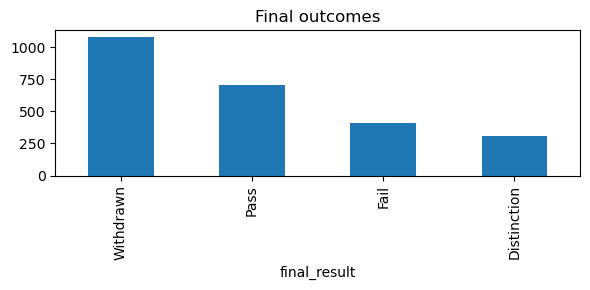

In [4]:
vc = students.final_result.value_counts()
display(vc.to_frame("count").assign(pct=(vc/len(students)*100).round(1)))
for k,v in vc.items(): notes.append(f"{k}: {v} ({v/len(students)*100:.1f}%)")
vc.plot(kind="bar", title="Final outcomes", figsize=(6,3)); plt.tight_layout(); plt.show()

## Build the weekly feature grid
One row per student per week: clicks, active days, distinct types, recency.

In [5]:
sv = sv[sv.date >= 0].copy()
sv["week"] = (sv.date // DAYS_PER_WEEK).astype(int)
max_week = int(sv.week.max())
if len(asm): max_week = max(max_week, int(asm.date.max() // DAYS_PER_WEEK))
weeks = np.arange(0, max_week + 1)
say(f"Weeks 0..{max_week}")

grid = (students[["id_student"]].assign(_k=1)
        .merge(pd.DataFrame({"week":weeks,"_k":1}), on="_k").drop(columns="_k"))
grid["week_end_day"] = grid.week*DAYS_PER_WEEK + (DAYS_PER_WEEK-1)

wk = sv.groupby(["id_student","week"]).agg(clicks=("sum_click","sum"), active_days=("date","nunique")).reset_index()
grid = grid.merge(wk, on=["id_student","week"], how="left")
grid[["clicks","active_days"]] = grid[["clicks","active_days"]].fillna(0)

svt = sv.merge(vle[["id_site","activity_type"]], on="id_site", how="left")
bt = svt.groupby(["id_student","week"]).activity_type.nunique().reset_index(name="n_types")
grid = grid.merge(bt, on=["id_student","week"], how="left"); grid["n_types"] = grid.n_types.fillna(0)

last_day = sv.groupby(["id_student","week"]).date.max().reset_index(name="lad")
grid = grid.merge(last_day, on=["id_student","week"], how="left").sort_values(["id_student","week"]).reset_index(drop=True)
grid["lad"] = grid.groupby("id_student").lad.ffill()
grid["recency_days"] = (grid.week_end_day - grid.lad).clip(lower=0)
grid.head()

Weeks 0..38


,id_student,week,week_end_day,clicks,active_days,n_types,lad,recency_days
0,23698,0,6,25.0,4.0,4.0,6.0,0.0
1,23698,1,13,140.0,6.0,5.0,13.0,0.0
2,23698,2,20,6.0,3.0,3.0,19.0,1.0
3,23698,3,27,13.0,4.0,6.0,26.0,1.0
4,23698,4,34,4.0,1.0,2.0,29.0,5.0


## 3. Weekly clicks — distribution and skew
If this is strongly right-skewed, percentile scaling is the right call.

Zero-click student-weeks: 55.4%
All weeks:    p0=0.0, p10=0.0, p25=0.0, p50=0.0, p75=18.0, p90=84.0, p95=144.0, p99=340.8, p100=3899.0
Active weeks: p0=1.0, p10=2.0, p25=6.0, p50=25.0, p75=75.0, p90=155.0, p95=232.0, p99=479.0, p100=3899.0
Skew (active): 6.95


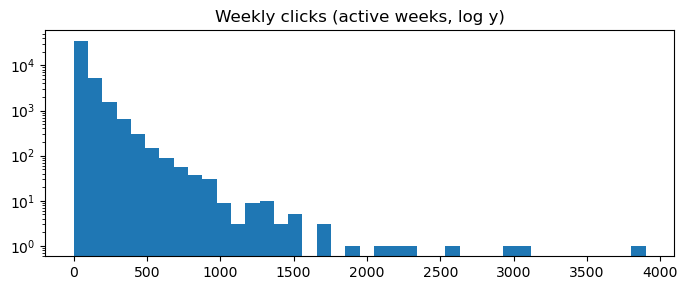

In [6]:
say(f"Zero-click student-weeks: {(grid.clicks==0).mean()*100:.1f}%")
say(f"All weeks:    {pct_table(grid.clicks)}")
say(f"Active weeks: {pct_table(grid.clicks[grid.clicks>0])}")
say(f"Skew (active): {grid.clicks[grid.clicks>0].skew():.2f}")
plt.figure(figsize=(7,3)); plt.hist(grid.clicks[grid.clicks>0], bins=40); plt.yscale("log")
plt.title("Weekly clicks (active weeks, log y)"); plt.tight_layout(); plt.show()

## 4. Active days per week (0–7)

active-day counts 0..7: [53948, 12814, 9594, 7541, 5593, 3866, 2395, 1671]


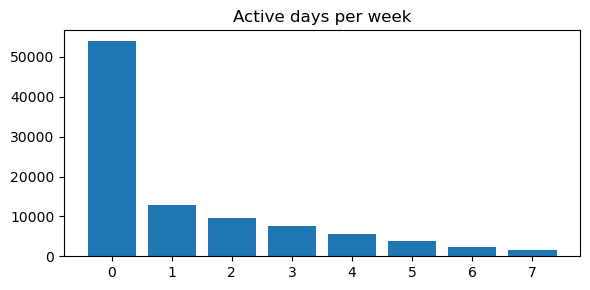

In [7]:
counts = [int((grid.active_days==d).sum()) for d in range(8)]
say("active-day counts 0..7: " + str(counts))
plt.figure(figsize=(6,3)); plt.bar(range(8), counts); plt.title("Active days per week"); plt.tight_layout(); plt.show()

## 5. Activity types (Area 2 / breadth)

9 types available: ['forumng', 'homepage', 'oucollaborate', 'oucontent', 'page', 'quiz', 'resource', 'subpage', 'url']
Distinct types per active week: p0=1.0, p10=1.0, p25=2.0, p50=4.0, p75=5.0, p90=6.0, p95=7.0, p99=7.0, p100=9.0


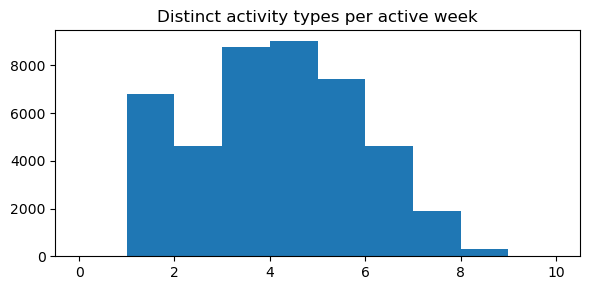

In [8]:
types = sorted(vle.activity_type.dropna().unique().tolist())
say(f"{len(types)} types available: {types}")
say(f"Distinct types per active week: {pct_table(grid.n_types[grid.n_types>0])}")
plt.figure(figsize=(6,3)); plt.hist(grid.n_types[grid.n_types>0], bins=range(0,int(grid.n_types.max())+2))
plt.title("Distinct activity types per active week"); plt.tight_layout(); plt.show()

## 6. Recency (days since last click)

Recency across all student-weeks: p0=0.0, p10=0.0, p25=1.0, p50=6.0, p75=50.0, p90=148.0, p95=191.0, p99=239.0, p100=272.0


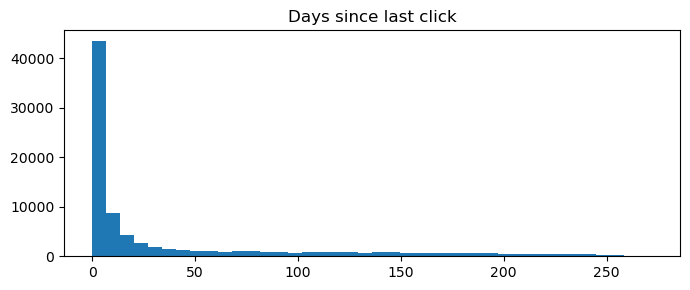

In [9]:
say(f"Recency across all student-weeks: {pct_table(grid.recency_days)}")
plt.figure(figsize=(7,3)); plt.hist(grid.recency_days, bins=40); plt.title("Days since last click"); plt.tight_layout(); plt.show()

## 7. Assessments (Area 5)

In [10]:
if len(asm):
    asm = asm.copy(); asm["due_week"] = (asm.date // DAYS_PER_WEEK).astype(int)
    say(f"{len(asm)} assessments | types {asm.assessment_type.value_counts().to_dict()} | due weeks {sorted(asm.due_week.tolist())}")
if len(sa):
    sub = sa.merge(asm[["id_assessment","date"]], on="id_assessment", how="left").dropna(subset=["date_submitted"])
    sub["ontime"] = (sub.date_submitted <= sub.date)
    say(f"Submissions {len(sub)} | on-time {sub.ontime.mean()*100:.1f}% | scores {pct_table(pd.to_numeric(sub.score, errors='coerce'))}")
    say(f"Per-student submission rate: {pct_table((sub.groupby('id_student').size()/len(asm)).clip(0,1))}")

8 assessments | types {'CMA': 4, 'TMA': 4} | due weeks [2, 4, 9, 15, 20, 22, 29, 30]
Submissions 10283 | on-time 35.4% | scores p0=0.0, p10=44.0, p25=63.0, p50=81.0, p75=93.0, p90=99.0, p95=100.0, p99=100.0, p100=100.0
Per-student submission rate: p0=0.1, p10=0.1, p25=0.4, p50=0.6, p75=1.0, p90=1.0, p95=1.0, p99=1.0, p100=1.0


## 8. Cohort mean clicks per week
Dips here are whole-class effects (holidays, exam weeks) — the reason Area 4 compares within a week.

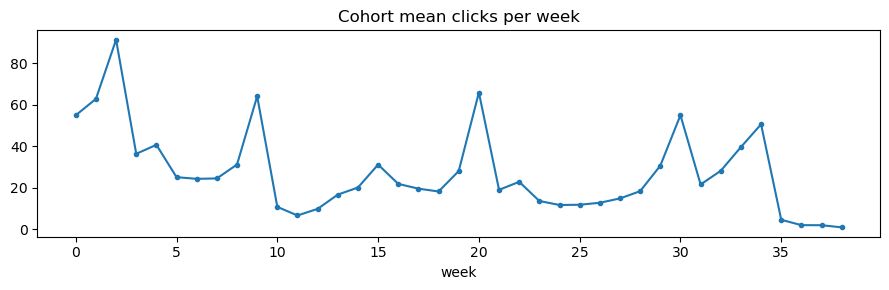

In [11]:
cohort = grid.groupby("week").clicks.mean()
plt.figure(figsize=(9,3)); plt.plot(cohort.index, cohort.values, marker="o", ms=3)
plt.title("Cohort mean clicks per week"); plt.xlabel("week"); plt.tight_layout(); plt.show()

## 9. Feature correlation heatmap
Shows how much the features overlap. Values near +/-1 = redundant; near 0 = independent.
Recency should correlate **negatively** with the activity features (more silence = less of everything).

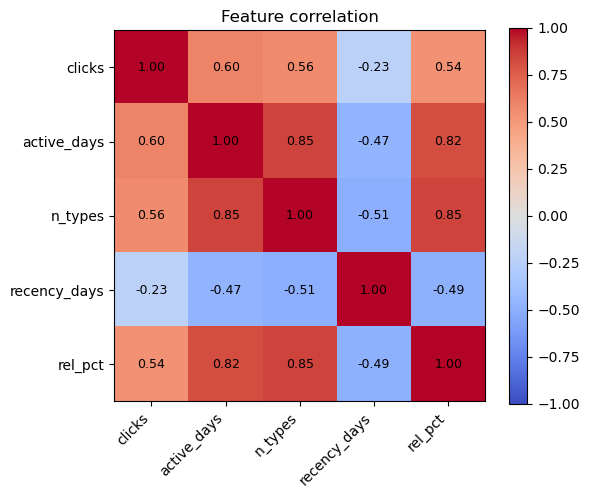

,clicks,active_days,n_types,recency_days,rel_pct
clicks,1.00,0.60,0.56,-0.23,0.54
active_days,0.60,1.00,0.85,-0.47,0.82
n_types,0.56,0.85,1.00,-0.51,0.85
recency_days,-0.23,-0.47,-0.51,1.00,-0.49
rel_pct,0.54,0.82,0.85,-0.49,1.00


In [12]:
grid["rel_pct"] = grid.groupby("week").clicks.rank(pct=True)
feat = grid[["clicks","active_days","n_types","recency_days","rel_pct"]]
corr = feat.corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im); ax.set_title("Feature correlation"); plt.tight_layout(); plt.show()
display(corr.round(2))

## 10. Signal check — early clicks by outcome
Engaged outcomes should sit clearly above Withdrawn.

Distinction: 99.4
Pass: 69.8
Fail: 44.3
Withdrawn: 29.5


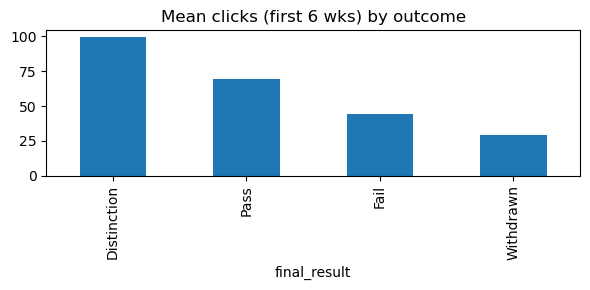


[saved eda_summary.md]


In [14]:
early = grid[grid.week < EARLY_WEEKS].merge(students, on="id_student")
by_out = early.groupby("final_result").clicks.mean().sort_values(ascending=False)
for k,v in by_out.items(): say(f"{k}: {v:.1f}")
by_out.plot(kind="bar", title=f"Mean clicks (first {EARLY_WEEKS} wks) by outcome", figsize=(6,3))
plt.tight_layout(); plt.show()

with open("eda_summary.md","w") as f: f.write("\n".join(notes))
print("\n[saved eda_summary.md]")